In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import median_abs_deviation
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

In [73]:
plt.rcParams["figure.figsize"] = (10, 6)

In [74]:
df = pd.read_csv("/content/ec2_cpu_utilization_24ae8d.csv")
df.head()

,timestamp,value
0,2014-02-14 14:30:00,0.132
1,2014-02-14 14:35:00,0.134
2,2014-02-14 14:40:00,0.134
3,2014-02-14 14:45:00,0.134
4,2014-02-14 14:50:00,0.134


**Create Label**

In [75]:
anomaly_timestamps = [
    "2014-02-26 22:05:00",
    "2014-02-27 17:15:00"
]

In [76]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [77]:
df['is_anomaly'] = 1
df.loc[
    df["timestamp"].isin(pd.to_datetime(anomaly_timestamps)),
    "is_anomaly"
] = -1


**Visualization**

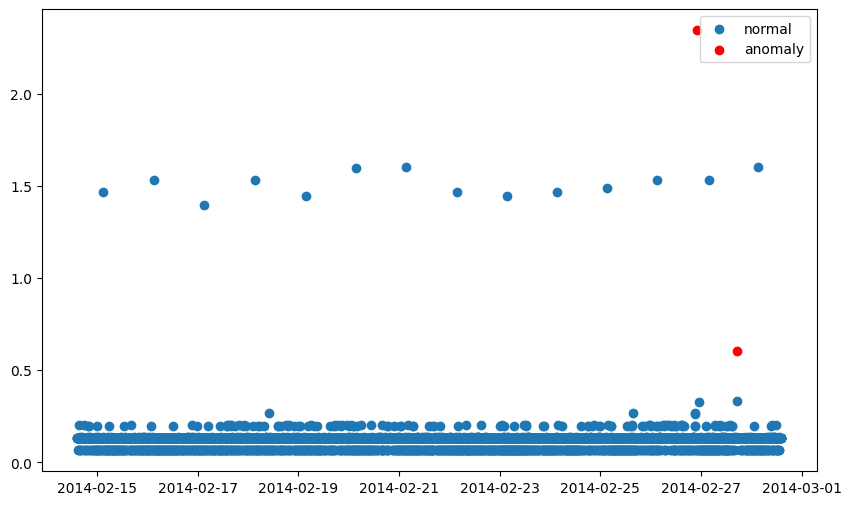

In [78]:
normal = df[df['is_anomaly'] == 1]
anomaly = df[df['is_anomaly'] == -1]

plt.scatter(
    normal['timestamp'],
    normal['value'],
    label = 'normal'
)

plt.scatter(
    anomaly['timestamp'],
    anomaly['value'],
    label='anomaly',
    color='red'
)
plt.legend()
plt.show()

**Robust Z Score**

In [79]:
median = np.median(df['value'])
mad = median_abs_deviation(df['value'])
df['z_score'] = 0.6745 * (df['value'] - median) / mad

**Baseline prediction**

In [80]:
df['baseline'] = 1
threshold = 3.5

df.loc[
    df['z_score'].abs() > threshold,
    'baseline'
] = 1

**Confusion matrix**

In [81]:
def plot_confusion_matrix(y_true, y_pred, title):

  cm = confusion_matrix(
      y_true,
      y_pred,
      labels=[1, -1]
  )
  disp = ConfusionMatrixDisplay(
      confusion_matrix=cm,
      display_labels= ['normal', 'anomaly']
  )
  disp.plot()
  plt.title(title)
  plt.show()

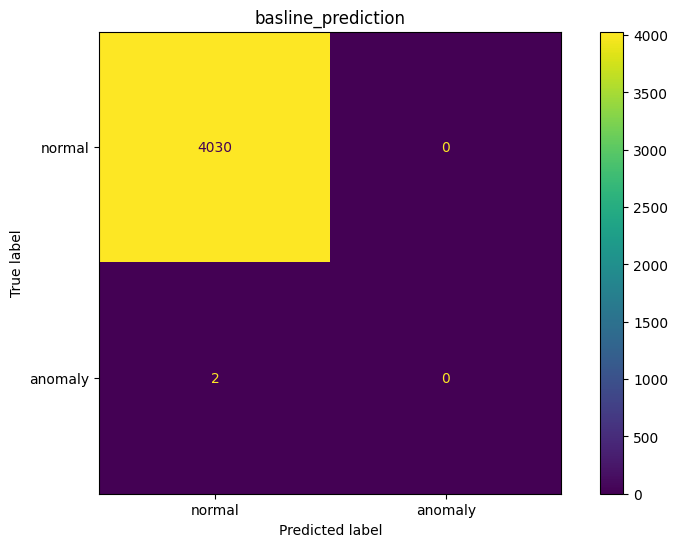

In [82]:
plot_confusion_matrix(
    df['is_anomaly'],
    df['baseline'],
    "basline_prediction"
)